# 02 - EDA y Preparacion para Inversion

Este notebook hace un analisis financiero profundo orientado a gestion de activos.
No depende de una carga manual dentro del notebook: intenta usar variables ya creadas en sesion.


In [34]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pyarrow as pa
import pyarrow.parquet as pq

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


## 1) Construir DataFrame de trabajo

Si no encuentra datos en memoria, ejecuta antes en este mismo kernel:
`%run -i notebooks/01_data_loading.ipynb`


In [35]:
# Priorizamos objetos frecuentes del flujo del proyecto
nombres_prioritarios = [
    "df_prepared", "pf", "PARQUET_PATH", "parquet"
]

nombre_origen = next((n for n in nombres_prioritarios if n in globals()), None)
objeto_origen = globals().get(nombre_origen, None)

datos_crudos_df = None
tipo_origen = None

if isinstance(objeto_origen, pd.DataFrame):
    datos_crudos_df = objeto_origen.copy()
    tipo_origen = "pandas.DataFrame"
elif isinstance(objeto_origen, pq.ParquetFile):
    datos_crudos_df = objeto_origen.read().to_pandas()
    tipo_origen = "pyarrow.parquet.ParquetFile"
elif isinstance(objeto_origen, pa.Table):
    datos_crudos_df = objeto_origen.to_pandas()
    tipo_origen = "pyarrow.Table"
elif isinstance(objeto_origen, str):
    try:
        datos_crudos_df = pq.read_table(objeto_origen).to_pandas()
        tipo_origen = "ruta parquet"
    except Exception:
        datos_crudos_df = None
elif "pf" in globals() and isinstance(globals()["pf"], pq.ParquetFile):
    datos_crudos_df = globals()["pf"].read().to_pandas()
    nombre_origen = "pf"
    tipo_origen = "pyarrow.parquet.ParquetFile (pf)"
elif "PARQUET_PATH" in globals():
    try:
        datos_crudos_df = pq.read_table(globals()["PARQUET_PATH"]).to_pandas()
        nombre_origen = "PARQUET_PATH"
        tipo_origen = "ruta parquet (PARQUET_PATH)"
    except Exception:
        datos_crudos_df = None

if datos_crudos_df is None:
    raise ValueError(
        "No pude construir el DataFrame. En este mismo notebook ejecuta `%run -i notebooks/01_data_loading.ipynb` "
        "o define `PARQUET_PATH` con la ruta de un parquet valido."
    )

print("Origen detectado:", nombre_origen)
print("Tipo detectado:", tipo_origen)
print("Shape inicial:", datos_crudos_df.shape)
display(datos_crudos_df.head())


Origen detectado: df_prepared
Tipo detectado: pandas.DataFrame
Shape inicial: (7250110, 14)


,date,symbol,open,high,low,close,unadjusted_close,volume,retorno_1d,log_retorno_1d,volatilidad_21d_anual,maximo_rolling_252d,drawdown,dollar_volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0,NaN,NaN,NaN,NaN,NaN,1.912361e+09
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0,-0.046784,-0.047913,NaN,NaN,NaN,4.440487e+08
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5,0.070552,0.068175,NaN,NaN,NaN,2.052600e+08
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0,-0.077364,-0.080520,NaN,NaN,NaN,1.720406e+08
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5,0.020186,0.019985,NaN,NaN,NaN,1.422569e+08


## 2) Seleccion de columnas relevantes

El analisis se centra en fecha, identificador de activo, precios y volumen.
Se excluyen columnas no utiles para evaluar riesgo/rentabilidad.


In [36]:
# Copia base y normalizacion de nombres

datos_base_df = datos_crudos_df.copy()
datos_base_df.columns = [str(c).strip().lower() for c in datos_base_df.columns]

# Detectamos columnas estructurales
columnas_fecha_candidatas = ["date", "datetime", "timestamp", "fecha"]
columna_fecha = next((c for c in columnas_fecha_candidatas if c in datos_base_df.columns), None)

columnas_activo_candidatas = ["symbol", "ticker", "asset", "activo"]
columna_activo = next((c for c in columnas_activo_candidatas if c in datos_base_df.columns), None)

# Priorizamos precio ajustado para analisis de retornos
columnas_precio_orden = ["adj_close", "close", "unadjusted_close"]
columna_precio_referencia = next((c for c in columnas_precio_orden if c in datos_base_df.columns), None)

# Detectamos columnas de precio disponibles
columnas_precio_disponibles = [c for c in ["open", "high", "low", "close", "adj_close", "unadjusted_close"] if c in datos_base_df.columns]

# Detectamos volumen
columna_volumen = "volume" if "volume" in datos_base_df.columns else None

# Armamos lista final de columnas relevantes sin duplicar
columnas_relevantes = []
for c in [columna_fecha, columna_activo] + columnas_precio_disponibles + [columna_volumen]:
    if c is not None and c not in columnas_relevantes:
        columnas_relevantes.append(c)

if not columnas_relevantes:
    raise ValueError("No encontre columnas financieras utiles en el dataset.")

datos_financieros_df = datos_base_df[columnas_relevantes].copy()

# Parse de fecha cuando exista
if columna_fecha is not None:
    datos_financieros_df[columna_fecha] = pd.to_datetime(datos_financieros_df[columna_fecha], errors="coerce")

print("Columnas analizadas:", columnas_relevantes)
print("Columna fecha:", columna_fecha)
print("Columna activo:", columna_activo)
print("Columna precio referencia:", columna_precio_referencia)
display(datos_financieros_df.head())


Columnas analizadas: ['date', 'symbol', 'open', 'high', 'low', 'close', 'unadjusted_close', 'volume']
Columna fecha: date
Columna activo: symbol
Columna precio referencia: close


,date,symbol,open,high,low,close,unadjusted_close,volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5


## 3) Auditoria de calidad de datos


In [37]:
# Ordenamos para preparar el analisis temporal
if columna_fecha is not None and columna_activo is not None:
    datos_financieros_df = datos_financieros_df.sort_values([columna_activo, columna_fecha]).reset_index(drop=True)
elif columna_fecha is not None:
    datos_financieros_df = datos_financieros_df.sort_values(columna_fecha).reset_index(drop=True)

# Duplicados exactos
duplicados_exactos = datos_financieros_df.duplicated().sum()

# Duplicados por clave economica (activo-fecha)
if columna_fecha is not None and columna_activo is not None:
    duplicados_clave = datos_financieros_df.duplicated(subset=[columna_activo, columna_fecha]).sum()
else:
    duplicados_clave = np.nan

# Nulos en columnas relevantes
resumen_nulos_df = (datos_financieros_df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%")

# Valores invalidos de mercado
conteo_precios_no_positivos = {}
for c in columnas_precio_disponibles:
    conteo_precios_no_positivos[c] = int((datos_financieros_df[c] <= 0).sum())

if columna_volumen is not None:
    conteo_volumen_negativo = int((datos_financieros_df[columna_volumen] < 0).sum())
else:
    conteo_volumen_negativo = np.nan

print("Filas, columnas:", datos_financieros_df.shape)
print("Duplicados exactos:", int(duplicados_exactos))
print("Duplicados activo-fecha:", duplicados_clave)
print("Volumen negativo:", conteo_volumen_negativo)
print("Precios <= 0 por columna:", conteo_precios_no_positivos)
display(resumen_nulos_df)


Filas, columnas: (7250110, 8)
Duplicados exactos: 0
Duplicados activo-fecha: 0
Volumen negativo: 0
Precios <= 0 por columna: {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'unadjusted_close': 0}


,missing_%
date,0.0
symbol,0.0
open,0.0
high,0.0
low,0.0
close,0.0
unadjusted_close,0.0
volume,0.0


No hay nulos en las columnas seleccionadas.


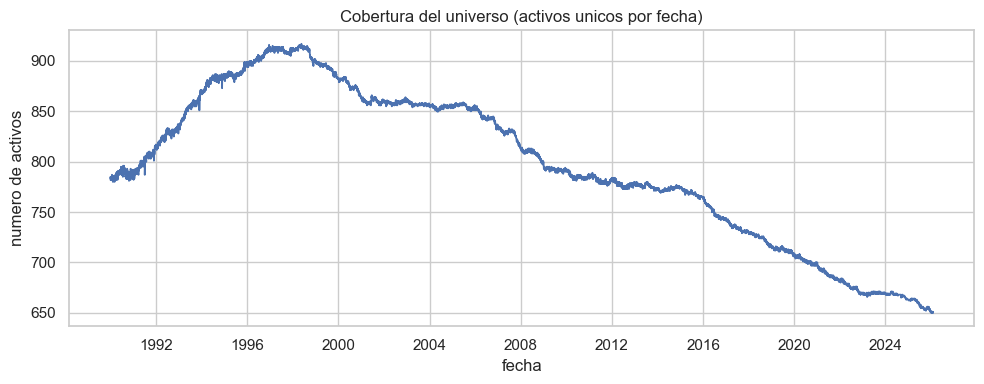

In [38]:
# Visual 1: porcentaje de nulos por columna
resumen_nulos_plot = resumen_nulos_df[resumen_nulos_df["missing_%"] > 0]
if len(resumen_nulos_plot) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=resumen_nulos_plot.index, y=resumen_nulos_plot["missing_%"], color="steelblue")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("% missing")
    plt.xlabel("columna")
    plt.title("Calidad de datos: faltantes por columna")
    plt.tight_layout()
    plt.show()
else:
    print("No hay nulos en las columnas seleccionadas.")

# Visual 2: cobertura del universo por fecha
if columna_fecha is not None and columna_activo is not None:
    cobertura_df = (
        datos_financieros_df.dropna(subset=[columna_fecha])
        .groupby(columna_fecha)[columna_activo]
        .nunique()
        .reset_index(name="n_activos")
    )
    plt.figure(figsize=(10, 4))
    plt.plot(cobertura_df[columna_fecha], cobertura_df["n_activos"], linewidth=1.3)
    plt.title("Cobertura del universo (activos unicos por fecha)")
    plt.xlabel("fecha")
    plt.ylabel("numero de activos")
    plt.tight_layout()
    plt.show()


## 4) Features de riesgo y rentabilidad


In [39]:
if columna_precio_referencia is None:
    raise ValueError("No hay columna de precio util para calcular retornos.")

datos_analisis_df = datos_financieros_df.copy()

# Retornos diarios y log-retornos
if columna_activo is not None:
    grupo_activo = datos_analisis_df.groupby(columna_activo)
    datos_analisis_df["retorno_1d"] = grupo_activo[columna_precio_referencia].pct_change()
else:
    datos_analisis_df["retorno_1d"] = datos_analisis_df[columna_precio_referencia].pct_change()

datos_analisis_df["log_retorno_1d"] = np.log1p(datos_analisis_df["retorno_1d"])

# Volatilidad rolling de 21 dias anualizada (proxy mensual de riesgo)
if columna_activo is not None:
    datos_analisis_df["volatilidad_21d_anual"] = (
        datos_analisis_df.groupby(columna_activo)["retorno_1d"]
        .transform(lambda s: s.rolling(21, min_periods=10).std() * np.sqrt(252))
    )
else:
    datos_analisis_df["volatilidad_21d_anual"] = (
        datos_analisis_df["retorno_1d"].rolling(21, min_periods=10).std() * np.sqrt(252)
    )

# Drawdown: perdida respecto al maximo rolling de 252 sesiones
if columna_activo is not None:
    datos_analisis_df["maximo_rolling_252d"] = (
        datos_analisis_df.groupby(columna_activo)[columna_precio_referencia]
        .transform(lambda s: s.rolling(252, min_periods=20).max())
    )
else:
    datos_analisis_df["maximo_rolling_252d"] = (
        datos_analisis_df[columna_precio_referencia].rolling(252, min_periods=20).max()
    )

datos_analisis_df["drawdown"] = (
    datos_analisis_df[columna_precio_referencia] / datos_analisis_df["maximo_rolling_252d"] - 1
)

# Liquidez monetaria aproximada
if columna_volumen is not None:
    datos_analisis_df["dollar_volume"] = (
        datos_analisis_df[columna_precio_referencia] * datos_analisis_df[columna_volumen]
    )

print("Shape con features:", datos_analisis_df.shape)
display(datos_analisis_df.head())


Shape con features: (7250110, 14)


,date,symbol,open,high,low,close,unadjusted_close,volume,retorno_1d,log_retorno_1d,volatilidad_21d_anual,maximo_rolling_252d,drawdown,dollar_volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0,NaN,NaN,NaN,NaN,NaN,1.912361e+09
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0,-0.046784,-0.047913,NaN,NaN,NaN,4.440487e+08
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5,0.070552,0.068175,NaN,NaN,NaN,2.052600e+08
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0,-0.077364,-0.080520,NaN,NaN,NaN,1.720406e+08
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5,0.020186,0.019985,NaN,NaN,NaN,1.422569e+08


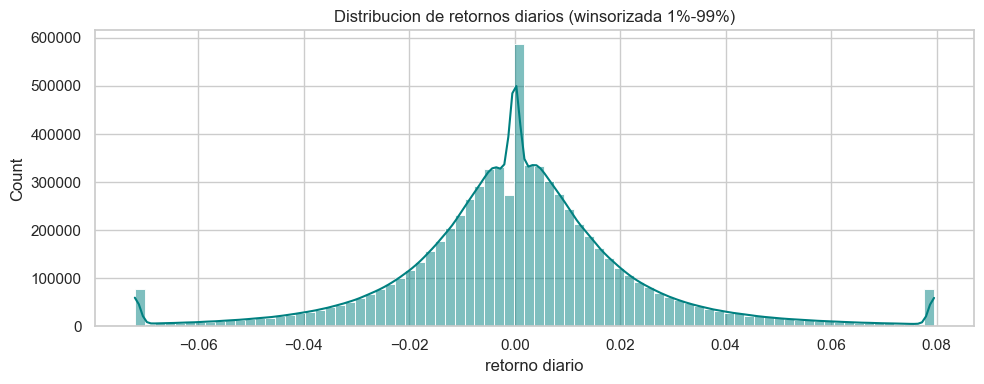

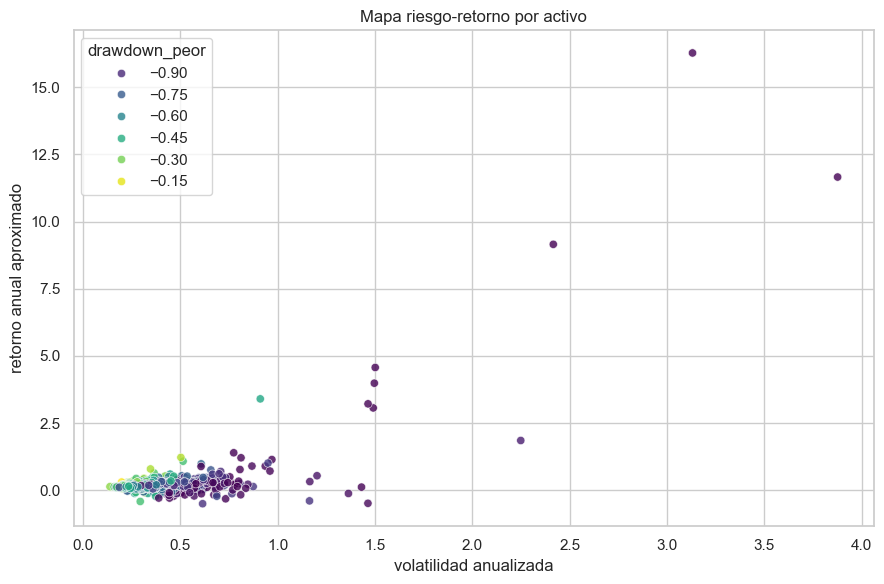

In [40]:
# Distribucion de retornos: colas y asimetria
retornos_validos = datos_analisis_df["retorno_1d"].dropna()
if len(retornos_validos) > 0:
    q_inf = retornos_validos.quantile(0.01)
    q_sup = retornos_validos.quantile(0.99)
    retornos_plot = retornos_validos.clip(lower=q_inf, upper=q_sup)

    plt.figure(figsize=(10, 4))
    sns.histplot(retornos_plot, bins=80, kde=True, color="teal")
    plt.title("Distribucion de retornos diarios (winsorizada 1%-99%)")
    plt.xlabel("retorno diario")
    plt.tight_layout()
    plt.show()

# Dispersion riesgo-retorno por activo (si hay identificador de activo)
if columna_activo is not None:
    resumen_rr_df = (
        datos_analisis_df.groupby(columna_activo)
        .agg(
            observaciones=(columna_precio_referencia, "count"),
            retorno_medio_diario=("retorno_1d", "mean"),
            volatilidad_media_anual=("volatilidad_21d_anual", "mean"),
            drawdown_peor=("drawdown", "min")
        )
        .reset_index()
    )

    resumen_rr_df = resumen_rr_df[resumen_rr_df["observaciones"] >= 126].copy()
    resumen_rr_df["retorno_anual_aprox"] = resumen_rr_df["retorno_medio_diario"] * 252

    if len(resumen_rr_df) > 0:
        plt.figure(figsize=(9, 6))
        sns.scatterplot(
            data=resumen_rr_df,
            x="volatilidad_media_anual",
            y="retorno_anual_aprox",
            hue="drawdown_peor",
            palette="viridis",
            alpha=0.8
        )
        plt.title("Mapa riesgo-retorno por activo")
        plt.xlabel("volatilidad anualizada")
        plt.ylabel("retorno anual aproximado")
        plt.tight_layout()
        plt.show()


## 5) Ranking de activos para gestion


In [41]:
if columna_activo is None:
    print("No hay columna de activo; no se puede crear ranking cross-sectional.")
    ranking_activos_df = pd.DataFrame()
else:
    agregaciones = {
        "observaciones": (columna_precio_referencia, "count"),
        "retorno_medio_diario": ("retorno_1d", "mean"),
        "volatilidad_media_anual": ("volatilidad_21d_anual", "mean"),
        "drawdown_peor": ("drawdown", "min")
    }

    if "dollar_volume" in datos_analisis_df.columns:
        agregaciones["liquidez_mediana"] = ("dollar_volume", "median")

    ranking_activos_df = datos_analisis_df.groupby(columna_activo).agg(**agregaciones)

    ranking_activos_df["retorno_anual_aprox"] = ranking_activos_df["retorno_medio_diario"] * 252
    ranking_activos_df["sharpe_aprox"] = (
        ranking_activos_df["retorno_anual_aprox"] /
        ranking_activos_df["volatilidad_media_anual"].replace(0, np.nan)
    )

    # Filtro minimo para evitar ranking con series muy cortas
    ranking_activos_df = ranking_activos_df[ranking_activos_df["observaciones"] >= 126]

    # Priorizamos Sharpe alto, drawdown menos profundo y liquidez
    columnas_orden = ["sharpe_aprox", "drawdown_peor"]
    ascendentes = [False, False]

    if "liquidez_mediana" in ranking_activos_df.columns:
        columnas_orden.append("liquidez_mediana")
        ascendentes.append(False)

    ranking_activos_df = ranking_activos_df.sort_values(columnas_orden, ascending=ascendentes)

    print("Top 20 activos segun perfil riesgo-retorno:")
    display(ranking_activos_df.head(20))


Top 20 activos segun perfil riesgo-retorno:


,observaciones,retorno_medio_diario,volatilidad_media_anual,drawdown_peor,liquidez_mediana,retorno_anual_aprox,sharpe_aprox
symbol,,,,,,,
YELLQ,8993,0.064602,3.130932,-0.999982,5.000032e+06,16.279663,5.199622
BIGGQ,9084,0.036331,2.416067,-0.999943,1.722162e+07,9.155400,3.789381
SNDK,242,0.013503,0.911268,-0.475009,2.274805e+08,3.402667,3.733992
SIVBQ-202411,8746,0.018139,1.501537,-0.999996,1.520378e+07,4.570991,3.044208
GWOW-201009,3319,0.046271,3.876087,-0.999855,1.852500e+04,11.660362,3.008281
FRCB,3806,0.015819,1.496945,-0.999932,5.087420e+07,3.986301,2.662957
GHC-199308,135,0.004856,0.503594,-0.218182,6.628088e+06,1.223786,2.430103
NRT-199008,153,0.003148,0.347457,-0.227658,1.242000e+07,0.793407,2.283467
MZIAQ-201302,5365,0.012768,1.464534,-0.997895,7.489625e+05,3.217596,2.197010


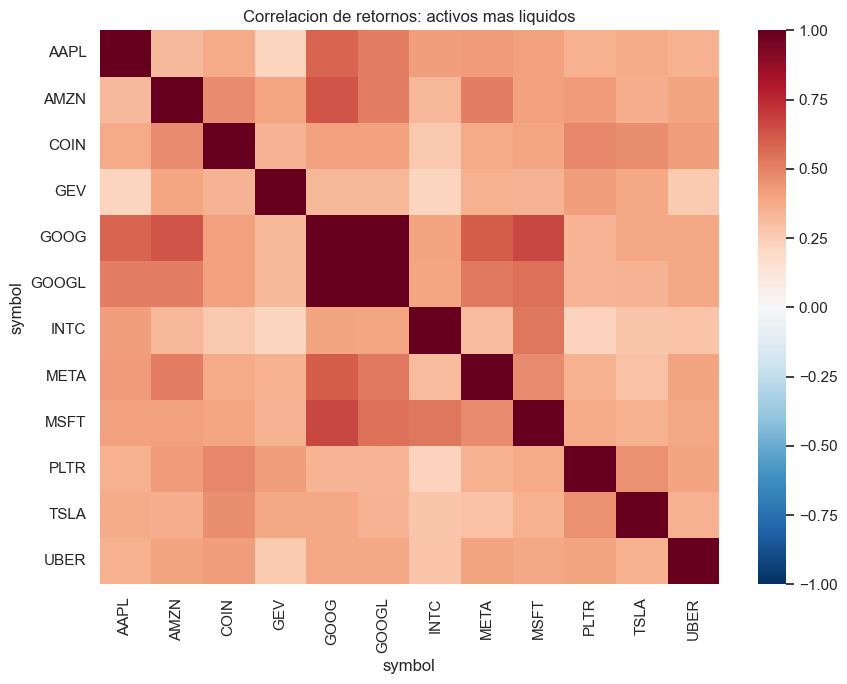

In [42]:
# Correlacion entre activos mas liquidos (util para diversificacion)
if columna_activo is not None and columna_fecha is not None:
    if "dollar_volume" in datos_analisis_df.columns:
        activos_liquidos = (
            datos_analisis_df.groupby(columna_activo)["dollar_volume"]
            .median()
            .sort_values(ascending=False)
            .head(12)
            .index
            .tolist()
        )
    else:
        activos_liquidos = (
            datos_analisis_df.groupby(columna_activo)[columna_precio_referencia]
            .count()
            .sort_values(ascending=False)
            .head(12)
            .index
            .tolist()
        )

    matriz_retornos = (
        datos_analisis_df[datos_analisis_df[columna_activo].isin(activos_liquidos)]
        .pivot(index=columna_fecha, columns=columna_activo, values="retorno_1d")
    )

    correlacion_df = matriz_retornos.corr(min_periods=60)

    plt.figure(figsize=(9, 7))
    sns.heatmap(correlacion_df, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
    plt.title("Correlacion de retornos: activos mas liquidos")
    plt.tight_layout()
    plt.show()


## 6) Salidas finales


In [43]:
# Dataset preparado para modelado / backtesting
df_prepared = datos_analisis_df.copy()

print("Variable final disponible: df_prepared")
print("Shape final:", df_prepared.shape)
print("Nulos top 10 (%):")
display((df_prepared.isna().mean() * 100).sort_values(ascending=False).head(10))

if "ranking_activos_df" in globals() and isinstance(ranking_activos_df, pd.DataFrame):
    print("Variable de ranking disponible: ranking_activos_df")


Variable final disponible: df_prepared
Shape final: (7250110, 14)
Nulos top 10 (%):


maximo_rolling_252d      0.337802
drawdown                 0.337802
volatilidad_21d_anual    0.177790
log_retorno_1d           0.017779
retorno_1d               0.017779
date                     0.000000
close                    0.000000
low                      0.000000
high                     0.000000
open                     0.000000
dtype: float64

Variable de ranking disponible: ranking_activos_df
